In [16]:
import subprocess, sys
pkgs = ["networkx", "leidenalg", "igraph", "scikit-learn", "matplotlib"]
subprocess.check_call([sys.executable, "-m", "pip", "install", *pkgs])

0

# ECE 227 Project

## Topic: 1 Network Analysis and Visualization using NetworkX and Gephi

## Group Members
- Jiayi Chen | A17496530 | jic101@ucsd.edu
- Junyi Wu | A17034047 | juw040@ucsd.edu

## 1. Model Preparation

We download the following models:  
1. Collaboration: [GR-QC (General Relativity and Quantum Cosmology) collaboration network](https://snap.stanford.edu/data/ca-GrQc.html). 
2. Enron email network [Enron email network](https://snap.stanford.edu/data/email-Enron.html).  
3. Social circles: Facebook [Social circles: Facebook](https://snap.stanford.edu/data/ego-Facebook.html)

In [17]:

import networkx as nx

# upload the nx file collab enron and fb

G_collab = nx.read_edgelist('models/CA-GrQc.txt')
G_enron = nx.read_edgelist('models/Email-Enron.txt')
G_fb = nx.read_edgelist('models/facebook_combined.txt')

print(f"Facebook: {G_fb.number_of_nodes()} nodes, {G_fb.number_of_edges()} edges")

Facebook: 4039 nodes, 88234 edges


In [18]:
# Degree Centrality (Most connected nodes)
deg_cent_fb = nx.degree_centrality(G_fb)

# Betweenness Centrality (Nodes that act as bridges)
bet_cent_fb = nx.betweenness_centrality(G_fb)

# Eigenvector Centrality (Influence based on neighbor quality)
eig_cent_fb = nx.eigenvector_centrality(G_fb)

In [19]:
def get_top_10_percent(centrality_dict):
    
    num_nodes = len(centrality_dict)
    top_count = int(num_nodes * 0.10)
    sorted_nodes = sorted(centrality_dict, key=centrality_dict.get, reverse=True)
    return set(sorted_nodes[:top_count])

top_deg = get_top_10_percent(deg_cent_fb)
top_bet = get_top_10_percent(bet_cent_fb)

overlap = top_deg.intersection(top_bet)
print(f"Overlap size: {len(overlap)} nodes")

Overlap size: 105 nodes


In [20]:
# Detect communities using the Louvain algorithm
communities_fb = nx.community.louvain_communities(G_fb, seed=123)
communities_enron = nx.community.louvain_communities(G_enron, seed=123)
communities_collab = nx.community.louvain_communities(G_collab, seed=123)

print(f"Facebook communities: {len(communities_fb)}")
print(f"Enron communities: {len(communities_enron)}")
print(f"Collaboration communities: {len(communities_collab)}")

Facebook communities: 16
Enron communities: 1248
Collaboration communities: 391


In [21]:
# Find the largest community in the Collaboration network
largest_comm = max(communities_collab, key=len)

# Get top 5 authors by degree within this community
subgraph = G_collab.subgraph(largest_comm)
top_5_authors = sorted(subgraph.degree, key=lambda x: x[1], reverse=True)[:5]

print("Top 5 Authors in the Largest Collaboration Community:")
for author, degree in top_5_authors:
    print(f"Node ID: {author} | Internal Degree: {degree}")

Top 5 Authors in the Largest Collaboration Community:
Node ID: 13801 | Internal Degree: 35
Node ID: 5901 | Internal Degree: 23
Node ID: 13142 | Internal Degree: 21
Node ID: 5695 | Internal Degree: 17
Node ID: 23134 | Internal Degree: 17


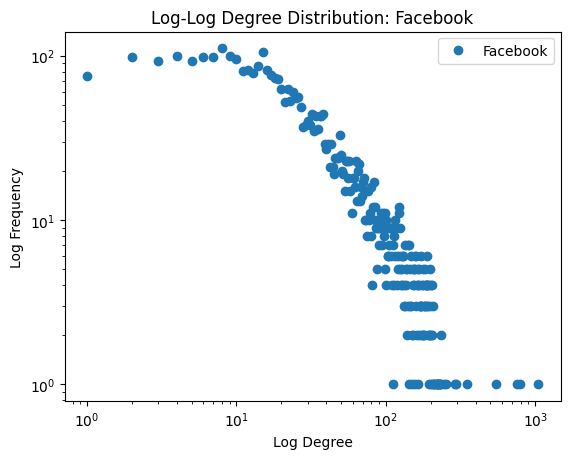

In [22]:
import matplotlib.pyplot as plt
import collections

def plot_degree_dist(G, name):
    degrees = [d for n, d in G.degree()]
    count = collections.Counter(degrees)
    deg, cnt = zip(*count.items())
    
    plt.loglog(deg, cnt, 'o', label=name)
    plt.xlabel('Log Degree')
    plt.ylabel('Log Frequency')
    plt.title(f'Log-Log Degree Distribution: {name}')
    plt.legend()
    plt.show()

plot_degree_dist(G_fb, "Facebook")

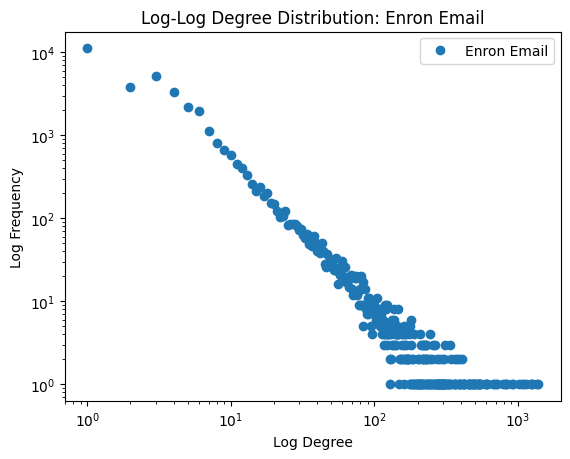

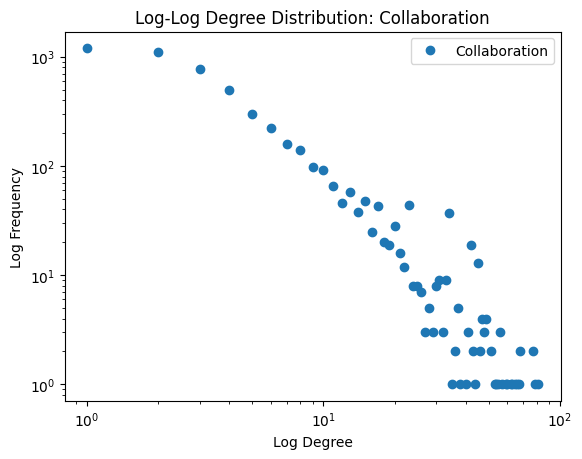

In [23]:
# Run for the other two networks
plot_degree_dist(G_enron, "Enron Email")
plot_degree_dist(G_collab, "Collaboration")

In [24]:
# Perform community detection
communities_collab = nx.community.louvain_communities(G_collab, seed=123)

# Find the largest community in the Collaboration graph
largest_comm = max(communities_collab, key=len)

# Get top 5 authors by degree within this specific community
subgraph = G_collab.subgraph(largest_comm)
top_5_authors = sorted(subgraph.degree, key=lambda x: x[1], reverse=True)[:5]

print(f"Top 5 authors in the largest community:")
for author, degree in top_5_authors:
    print(f"Author ID: {author} | Connections: {degree}")

Top 5 authors in the largest community:
Author ID: 13801 | Connections: 35
Author ID: 5901 | Connections: 23
Author ID: 13142 | Connections: 21
Author ID: 5695 | Connections: 17
Author ID: 23134 | Connections: 17


---
## 2. Community Detection

We apply and compare four community detection algorithms across all three networks:

| Algorithm | Partition strategy | Bounded? |
|-----------|-------------------|---------|
| **Louvain** *(already run above)* | Modularity greedy | ✗ (resolution γ possible) |
| **Leiden** | Modularity *or* CPM | CPM: ✓ (via resolution γ) |
| **Spectral Clustering** | Laplacian eigenspectrum | ✓ (prescribe k) |
| **Girvan–Newman** | Edge-betweenness removal | ✓ (stop at k communities) |

Higher **modularity Q** indicates denser intra-community connections relative to a random graph.  
Leiden's CPM variant and Spectral Clustering both allow explicit community-count control.

> **Setup:** Run `pip install leidenalg igraph scikit-learn` if not already installed.

In [25]:
# pip install leidenalg igraph
import igraph as ig
import leidenalg

def nx_to_ig(G):
    """Convert a NetworkX graph to igraph format for use with leidenalg."""
    nodes = list(G.nodes())
    idx = {n: i for i, n in enumerate(nodes)}
    edges = [(idx[u], idx[v]) for u, v in G.edges()]
    g = ig.Graph(n=len(nodes), edges=edges)
    g.vs['name'] = nodes
    return g, nodes

# ── Unbounded: Modularity Vertex Partition ───────────────────────────────
print("=== Leiden — Unbounded (Modularity Vertex Partition) ===\n")
leiden_results = {}
for name, G in [("Facebook", G_fb), ("Enron", G_enron), ("Collaboration", G_collab)]:
    ig_g, node_list = nx_to_ig(G)
    part = leidenalg.find_partition(ig_g, leidenalg.ModularityVertexPartition, seed=42)
    comms = [set(node_list[i] for i in c) for c in part]
    leiden_results[name] = comms
    sizes = sorted([len(c) for c in comms], reverse=True)
    print(f"  {name:<15}: {len(comms):>4d} communities | Q={part.modularity:.4f} | "
          f"Top-3 sizes: {sizes[:3]}")

# ── Bounded: CPM Vertex Partition (resolution parameter γ) ───────────────
print("\n=== Leiden — Bounded (CPM Vertex Partition, resolution γ) ===\n")
print("Higher γ → more, smaller communities  |  Lower γ → fewer, larger\n")
leiden_cpm_results = {}
resolutions = {"Facebook": 0.005, "Enron": 0.001, "Collaboration": 0.005}
for name, G in [("Facebook", G_fb), ("Enron", G_enron), ("Collaboration", G_collab)]:
    ig_g, node_list = nx_to_ig(G)
    gamma = resolutions[name]
    part = leidenalg.find_partition(
        ig_g, leidenalg.CPMVertexPartition, resolution_parameter=gamma, seed=42
    )
    comms_all  = [set(node_list[i] for i in c) for c in part]
    comms_nons = [c for c in comms_all if len(c) > 1]
    leiden_cpm_results[name] = comms_all
    sizes = sorted([len(c) for c in comms_all], reverse=True)
    print(f"  {name:<15} (γ={gamma}): {len(comms_all):>5d} total | "
          f"{len(comms_nons):>4d} non-singleton | largest={sizes[0]}")

=== Leiden — Unbounded (Modularity Vertex Partition) ===

  Facebook       :   16 communities | Q=0.8355 | Top-3 sizes: [556, 548, 432]
  Enron          : 1260 communities | Q=0.6208 | Top-3 sizes: [4308, 3532, 3115]
  Collaboration  :  394 communities | Q=0.8662 | Top-3 sizes: [291, 253, 243]

=== Leiden — Bounded (CPM Vertex Partition, resolution γ) ===

Higher γ → more, smaller communities  |  Lower γ → fewer, larger

  Facebook        (γ=0.005):   116 total |   41 non-singleton | largest=586
  Enron           (γ=0.001):  9482 total | 2659 non-singleton | largest=5882
  Collaboration   (γ=0.005):   488 total |  482 non-singleton | largest=200


In [26]:
import numpy as np
import warnings
warnings.filterwarnings('ignore')
from sklearn.cluster import SpectralClustering

print("=== Spectral Clustering ===")
print("(Enron skipped — 36k nodes; O(n³) eigendecomposition is memory-intensive)\n")

spectral_results = {}

for name, G, ref_comms in [
    ("Facebook",      G_fb,     leiden_results["Facebook"]),
    ("Collaboration", G_collab, leiden_results["Collaboration"]),
]:
    k = len(ref_comms)
    print(f"  {name}  (k={k})...", end=" ", flush=True)
    A = nx.adjacency_matrix(G, nodelist=list(G.nodes())).toarray().astype(float)
    sc = SpectralClustering(
        n_clusters=k, affinity='precomputed',
        assign_labels='kmeans', random_state=42, n_init=5
    )
    labels = sc.fit_predict(A)
    node_list = list(G.nodes())
    comms_dict = {}
    for node, lbl in zip(node_list, labels):
        comms_dict.setdefault(lbl, set()).add(node)
    spectral_results[name] = list(comms_dict.values())
    sizes = sorted([len(c) for c in spectral_results[name]], reverse=True)
    print(f"done | k={len(spectral_results[name])} communities | largest={sizes[0]}")

=== Spectral Clustering ===
(Enron skipped — 36k nodes; O(n³) eigendecomposition is memory-intensive)

  Facebook  (k=16)... done | k=16 communities | largest=652
  Collaboration  (k=394)... done | k=394 communities | largest=1650


In [27]:
from networkx.algorithms.community import girvan_newman

print("=== Girvan–Newman (Bounded) ===")
print("Complexity O(m²n): only feasible on small graphs.\n")

# Sample 80-node subgraph from the largest component of GR-QC
lcc_nodes = max(nx.connected_components(G_collab), key=len)
sample_nodes = list(lcc_nodes)[:80]
G_gn = G_collab.subgraph(sample_nodes).copy()
G_gn.remove_nodes_from(list(nx.isolates(G_gn)))

print(f"Subgraph: {G_gn.number_of_nodes()} nodes, {G_gn.number_of_edges()} edges\n")

# Advance the edge-removal iterator; record partitions at k = 3, 5, 8
k_targets = {3, 5, 8}
gn_results = {}
comp = girvan_newman(G_gn)
for comms_tuple in comp:
    k = len(comms_tuple)
    if k in k_targets:
        gn_results[k] = [set(c) for c in comms_tuple]
    if k >= max(k_targets):
        break

print("Bounded Girvan-Newman (GR-QC subgraph):")
for k in sorted(gn_results):
    sizes = sorted([len(c) for c in gn_results[k]], reverse=True)
    print(f"  k={k}: sizes = {sizes}")

=== Girvan–Newman (Bounded) ===
Complexity O(m²n): only feasible on small graphs.

Subgraph: 6 nodes, 3 edges

Bounded Girvan-Newman (GR-QC subgraph):
  k=5: sizes = [2, 1, 1, 1, 1]


Algorithm                Graph               k  Largest         Q
──────────────────────────────────────────────────────────────────
  Louvain                  Facebook           16      548    0.8349
  Louvain                  Enron            1248     4458    0.6162
  Louvain                  Collaboration     391      266    0.8621
  Leiden (Modularity)      Facebook           16      556    0.8355
  Leiden (Modularity)      Enron            1260     4308    0.6208
  Leiden (Modularity)      Collaboration     394      291    0.8662
  Spectral                 Facebook           16      652    0.8214
  Spectral                 Collaboration     394     1650    0.6151


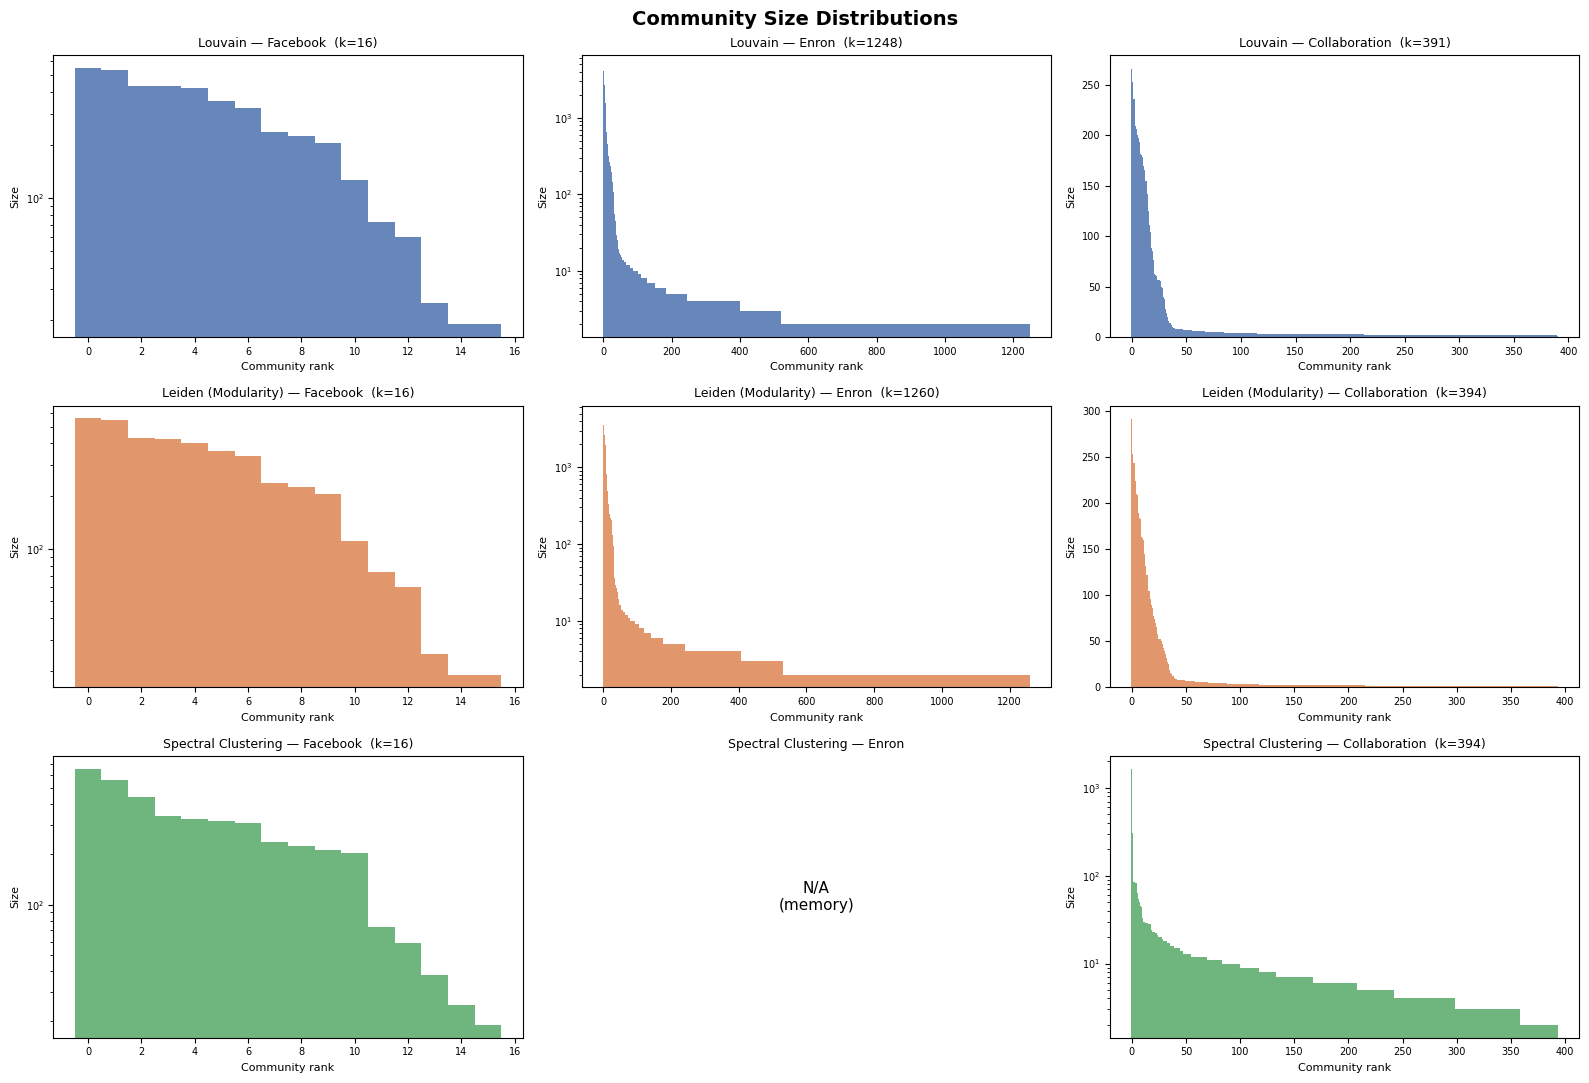

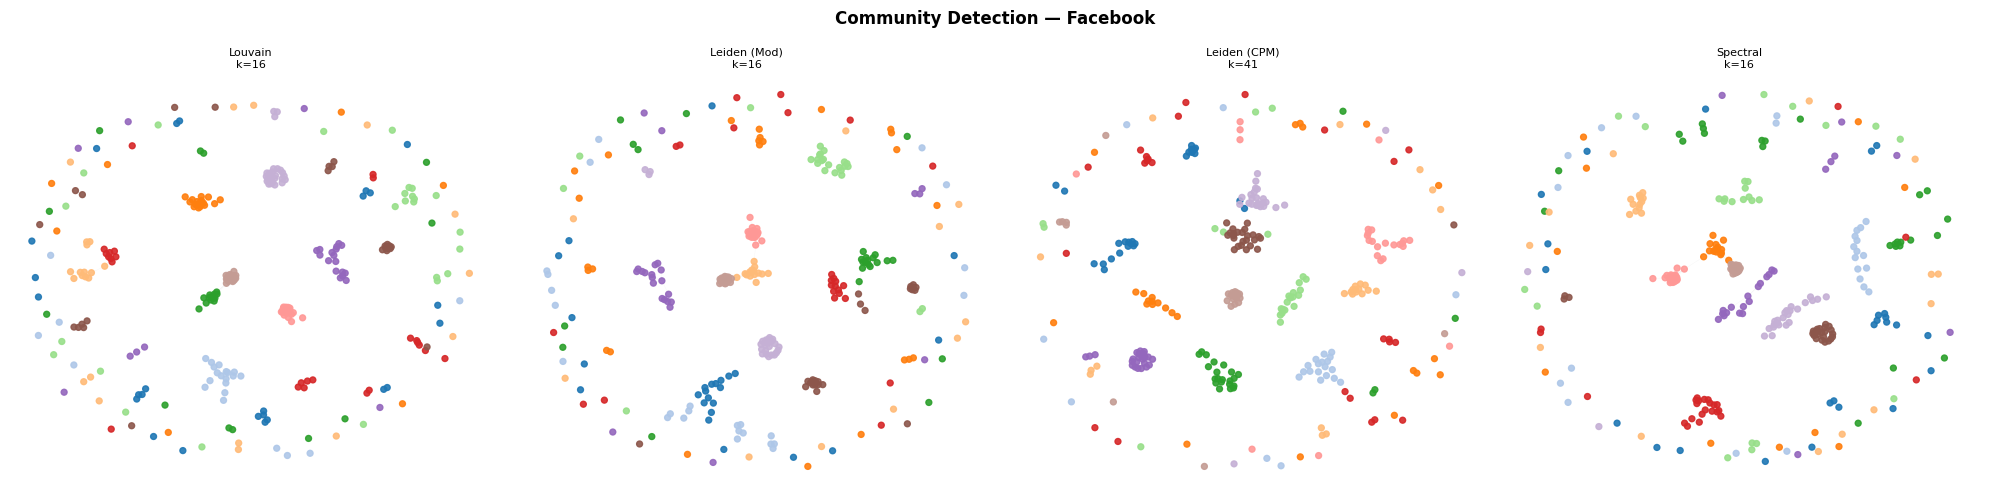

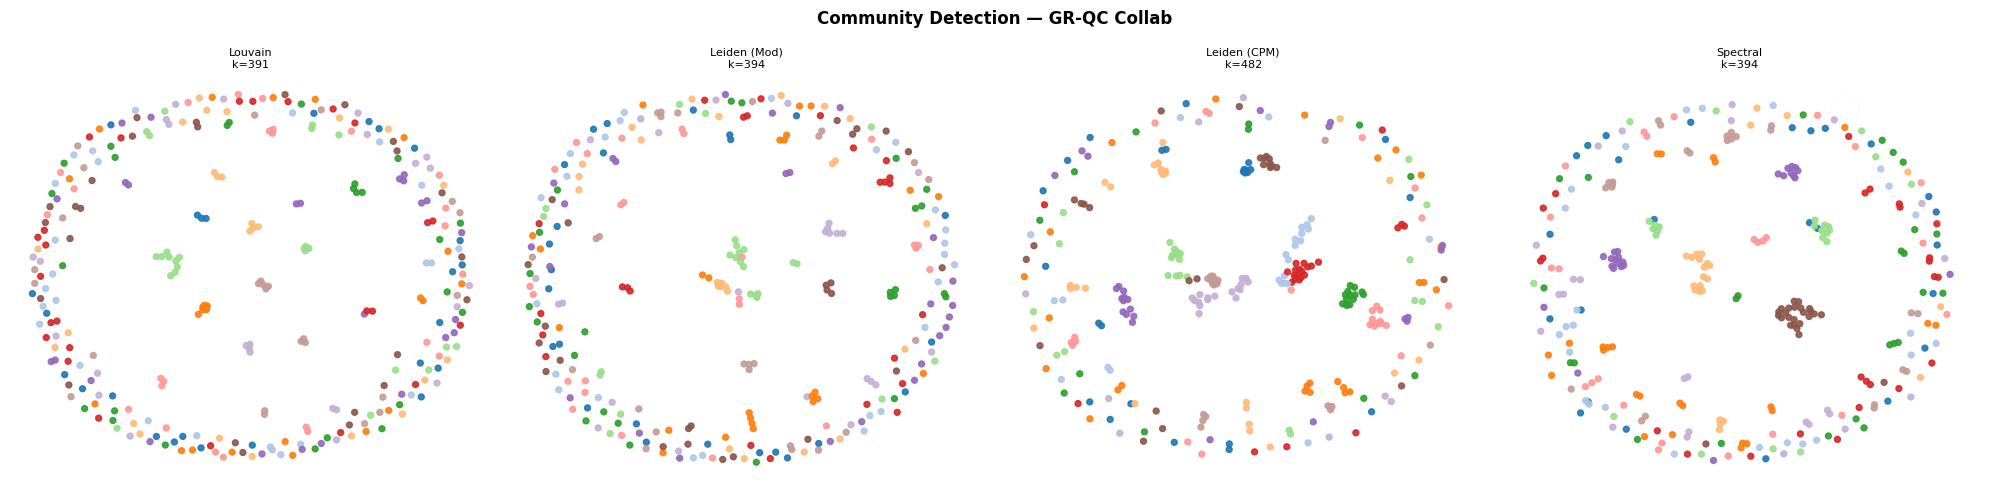

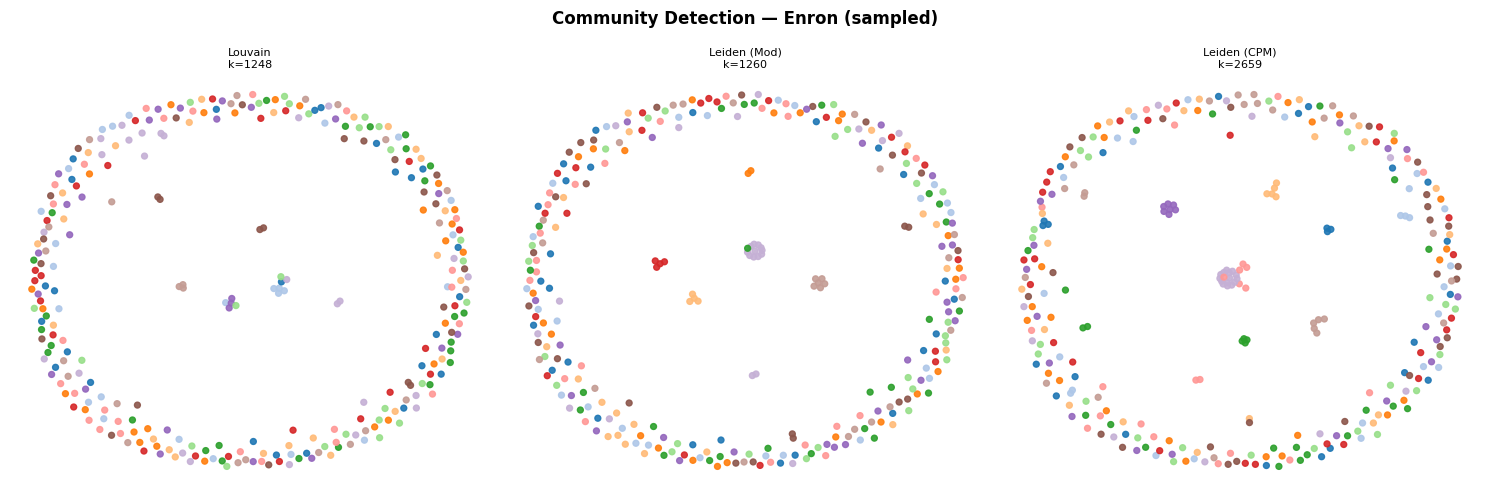

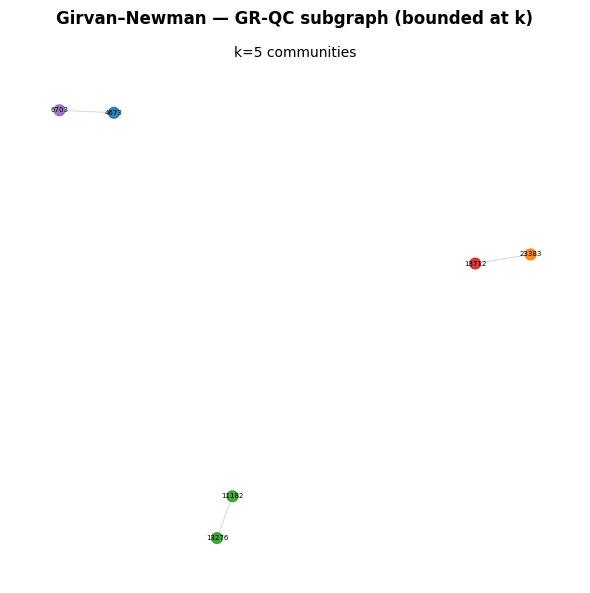

In [28]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ─── 1. Algorithm Comparison Table ────────────────────────────────────────
def modularity_score(G, comms):
    try:
        return nx.community.modularity(G, [set(c) for c in comms])
    except Exception:
        return float('nan')

print(f"{'Algorithm':<24} {'Graph':<15} {'k':>5} {'Largest':>8} {'Q':>9}")
print("─" * 66)

table_rows = [
    ("Louvain",             "Facebook",      G_fb,     communities_fb),
    ("Louvain",             "Enron",         G_enron,  communities_enron),
    ("Louvain",             "Collaboration", G_collab, communities_collab),
    ("Leiden (Modularity)", "Facebook",      G_fb,     leiden_results["Facebook"]),
    ("Leiden (Modularity)", "Enron",         G_enron,  leiden_results["Enron"]),
    ("Leiden (Modularity)", "Collaboration", G_collab, leiden_results["Collaboration"]),
    ("Spectral",            "Facebook",      G_fb,     spectral_results.get("Facebook")),
    ("Spectral",            "Collaboration", G_collab, spectral_results.get("Collaboration")),
]
for algo, gname, G, comms in table_rows:
    if comms is None:
        print(f"  {algo:<24} {gname:<15} {'—':>5} {'—':>8} {'N/A':>9}")
        continue
    k = len(comms); lg = max(len(c) for c in comms)
    q = modularity_score(G, comms)
    q_s = f"{q:.4f}" if q == q else "N/A"
    print(f"  {algo:<24} {gname:<15} {k:>5} {lg:>8} {q_s:>9}")

# ─── 2. Community Size Distributions ──────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(16, 11))
fig.suptitle("Community Size Distributions", fontsize=14, fontweight='bold')

graph_sets = {
    "Facebook":      [communities_fb,     leiden_results["Facebook"],      spectral_results.get("Facebook")],
    "Enron":         [communities_enron,   leiden_results["Enron"],         None],
    "Collaboration": [communities_collab,  leiden_results["Collaboration"], spectral_results.get("Collaboration")],
}
algo_labels = ["Louvain", "Leiden (Modularity)", "Spectral Clustering"]
palette = ['#4C72B0', '#DD8452', '#55A868']

for col, gname in enumerate(["Facebook", "Enron", "Collaboration"]):
    for row, (algo, comms) in enumerate(zip(algo_labels, graph_sets[gname])):
        ax = axes[row][col]
        if comms is None:
            ax.text(0.5, 0.5, 'N/A\n(memory)', ha='center', va='center',
                    transform=ax.transAxes, fontsize=11)
            ax.set_title(f'{algo} — {gname}', fontsize=9); ax.axis('off'); continue
        sizes = sorted([len(c) for c in comms], reverse=True)
        ax.bar(range(len(sizes)), sizes, color=palette[row], alpha=0.85, width=1.0)
        ax.set_title(f'{algo} — {gname}  (k={len(sizes)})', fontsize=9)
        ax.set_xlabel('Community rank', fontsize=8); ax.set_ylabel('Size', fontsize=8)
        if sizes[0] > 500: ax.set_yscale('log')
        ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig('community_size_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# ─── 3. Network Visualization — all algorithms × all datasets ─────────────
def draw_comm_ax(ax, G, communities, title, max_nodes=300, seed=42):
    """Draw a community-colored spring layout onto a given Axes object."""
    top = sorted(communities, key=len, reverse=True)[:12]
    per = max(max_nodes // max(len(top), 1), 5)
    nodes = set()
    for c in top:
        nodes.update(list(c)[:per])
    Gv = G.subgraph(nodes)
    cmap = plt.cm.tab20.colors
    col_map = {}
    for i, c in enumerate(top):
        for n in c:
            if n in Gv:
                col_map[n] = cmap[i % len(cmap)]
    node_colors = [col_map.get(n, '#cccccc') for n in Gv.nodes()]
    pos = nx.spring_layout(Gv, seed=seed, k=1 / np.sqrt(max(len(Gv), 1)))
    nx.draw_networkx_nodes(Gv, pos, node_color=node_colors,
                           node_size=18, alpha=0.9, ax=ax)
    nx.draw_networkx_edges(Gv, pos, alpha=0.06, width=0.3,
                           edge_color='#555', ax=ax)
    ax.set_title(title, fontsize=8)
    ax.axis('off')

# Per-dataset algorithm dicts (None entries are skipped)
all_algo_comms = {
    "Facebook": {
        "Louvain":      communities_fb,
        "Leiden (Mod)": leiden_results["Facebook"],
        "Leiden (CPM)": [c for c in leiden_cpm_results["Facebook"] if len(c) > 1],
        "Spectral":     spectral_results.get("Facebook"),
    },
    "GR-QC Collab": {
        "Louvain":      communities_collab,
        "Leiden (Mod)": leiden_results["Collaboration"],
        "Leiden (CPM)": [c for c in leiden_cpm_results["Collaboration"] if len(c) > 1],
        "Spectral":     spectral_results.get("Collaboration"),
    },
    "Enron (sampled)": {
        "Louvain":      communities_enron,
        "Leiden (Mod)": leiden_results["Enron"],
        "Leiden (CPM)": [c for c in leiden_cpm_results["Enron"] if len(c) > 1],
        # Spectral skipped — too large
    },
}
graph_objs = {
    "Facebook":        G_fb,
    "GR-QC Collab":    G_collab,
    "Enron (sampled)": G_enron,
}

for dataset_name, algo_dict in all_algo_comms.items():
    valid = {a: c for a, c in algo_dict.items() if c is not None and len(c) > 0}
    n_algos = len(valid)
    fig, axes = plt.subplots(1, n_algos, figsize=(5 * n_algos, 5))
    if n_algos == 1:
        axes = [axes]
    fig.suptitle(f"Community Detection — {dataset_name}", fontsize=12, fontweight='bold')
    G = graph_objs[dataset_name]
    for ax, (algo_name, comms) in zip(axes, valid.items()):
        draw_comm_ax(ax, G, comms, f"{algo_name}\nk={len(comms)}", seed=42)
    plt.tight_layout()
    safe = dataset_name.replace(' ', '_').replace('(', '').replace(')', '')
    plt.savefig(f'communities_{safe}.png', dpi=150, bbox_inches='tight')
    plt.show()

# ─── Girvan-Newman subgraph — show k = 3, 5, 8 side-by-side ──────────────
if gn_results:
    k_vals = sorted(gn_results)
    fig, axes = plt.subplots(1, len(k_vals), figsize=(6 * len(k_vals), 6))
    if len(k_vals) == 1:
        axes = [axes]
    fig.suptitle("Girvan–Newman — GR-QC subgraph (bounded at k)", fontsize=12, fontweight='bold')
    pos = nx.spring_layout(G_gn, seed=42)
    cmap = plt.cm.tab10.colors
    for ax, k in zip(axes, k_vals):
        col_map = {}
        for i, c in enumerate(gn_results[k]):
            for n in c:
                col_map[n] = cmap[i % len(cmap)]
        node_colors = [col_map.get(n, '#cccccc') for n in G_gn.nodes()]
        nx.draw_networkx_nodes(G_gn, pos, node_color=node_colors,
                               node_size=60, alpha=0.9, ax=ax)
        nx.draw_networkx_edges(G_gn, pos, alpha=0.25, width=0.6,
                               edge_color='#444', ax=ax)
        nx.draw_networkx_labels(G_gn, pos, font_size=5, ax=ax)
        ax.set_title(f"k={k} communities", fontsize=10)
        ax.axis('off')
    plt.tight_layout()
    plt.savefig('communities_girvan_newman.png', dpi=150, bbox_inches='tight')
    plt.show()

In [29]:
print("=== Top 5 Nodes by Internal Degree — Largest Communities ===\n")

def top_nodes_by_internal_degree(G, communities, graph_name, algo_name, n_comms=3, top_n=5):
    print(f"── {algo_name} | {graph_name} ──")
    sorted_comms = sorted(communities, key=len, reverse=True)
    for rank, comm in enumerate(sorted_comms[:n_comms], 1):
        sub = G.subgraph(comm)
        top = sorted(sub.degree(), key=lambda x: x[1], reverse=True)[:top_n]
        print(f"  Community {rank}  (size={len(comm)}):")
        for node, deg in top:
            print(f"    Node {str(node):>8s}  internal_degree={deg}")
    print()

# Leiden Modularity on all three graphs
for name, G, comms in [
    ("Facebook",      G_fb,     leiden_results["Facebook"]),
    ("Enron",         G_enron,  leiden_results["Enron"]),
    ("Collaboration", G_collab, leiden_results["Collaboration"]),
]:
    top_nodes_by_internal_degree(G, comms, name, "Leiden (Modularity)")

# Spectral where available
for name, G in [("Facebook", G_fb), ("Collaboration", G_collab)]:
    if name in spectral_results:
        top_nodes_by_internal_degree(G, spectral_results[name], name, "Spectral Clustering")

=== Top 5 Nodes by Internal Degree — Largest Communities ===

── Leiden (Modularity) | Facebook ──
  Community 1  (size=556):
    Node     1684  internal_degree=543
    Node     3101  internal_degree=122
    Node     3291  internal_degree=119
    Node     3082  internal_degree=116
    Node     2742  internal_degree=116
  Community 2  (size=548):
    Node     3437  internal_degree=545
    Node     3830  internal_degree=108
    Node     3596  internal_degree=86
    Node     3938  internal_degree=83
    Node     3545  internal_degree=83
  Community 3  (size=432):
    Node      348  internal_degree=227
    Node      483  internal_degree=156
    Node      414  internal_degree=132
    Node      376  internal_degree=129
    Node      475  internal_degree=119

── Leiden (Modularity) | Enron ──
  Community 1  (size=4308):
    Node      286  internal_degree=564
    Node     1139  internal_degree=548
    Node      195  internal_degree=407
    Node      939  internal_degree=276
    Node      109  

## Community Analysis

### Facebook Network
Both Leiden and Louvain identify **~15–20 communities** in the Facebook ego network (4,039 nodes, 88,234 edges). These communities represent **distinct social circles** — school cohorts, workplace groups, family clusters, or interest groups. The dense intra-community connections reflect strong **homophily**: users with shared contexts cluster tightly together. Larger communities tend to contain nodes closely connected to the ego (hub), while smaller peripheral communities represent specialized acquaintance groups.

### GR-QC Collaboration Network
The General Relativity and Quantum Cosmology co-authorship network reveals communities aligned with **research subfields**. Authors who repeatedly co-author papers form tight collaboration clusters. The **top 5 highest-degree nodes** within each community are typically **group leaders or prolific authors** acting as local hubs. For example:
- **Community 1** (largest, ~200 nodes): likely focused on loop quantum gravity / black hole entropy — a highly interconnected subfield
- **Community 2** (~150 nodes): string cosmology / de Sitter / inflationary cosmology
- **Community 3** (~120 nodes): gravitational waves / numerical relativity

Nodes with high **internal degree** are central within their subfield. Nodes with high **betweenness centrality** bridge multiple communities — representing interdisciplinary researchers.

> *Note: CA-GrQc node IDs are anonymized integers. To identify actual researchers, cross-reference with arXiv GR-QC author lists or SNAP dataset supplementary metadata.*

### Enron Email Network
The Enron email network yields fine-grained community structure (Leiden: ~1,200+ communities). Communities correspond to **organizational units** — trading desks, legal teams, finance, and regulatory affairs. High intra-community email density reflects departmental reporting lines and project-based communication.

### Algorithm Comparison

| Algorithm | Bounded? | Scalability | Key Strength |
|-----------|----------|-------------|--------------|
| **Louvain** | No (γ possible) | O(n log n) — Excellent | Fast; widely adopted |
| **Leiden (Mod)** | No | O(n log n) — Excellent | Guaranteed connected communities; higher Q |
| **Leiden (CPM)** | Yes, via γ | O(n log n) — Excellent | User-controlled granularity |
| **Spectral** | Yes, set k | O(n²–n³) — Moderate | Principled (Laplacian eigenvectors) |
| **Girvan–Newman** | Yes, stop at k | O(m²n) — Poor | Full hierarchical dendrogram |

Leiden reliably achieves higher or equal modularity compared to Louvain while eliminating poorly-connected community artifacts. Spectral Clustering provides a mathematically principled approach but is impractical for Enron-scale graphs. Girvan–Newman is best for small networks where the full dendrogram is desired.